# Synaptic Plasticity and Learning (CCNSS2026)

## Tutorial 3: Temporal-difference learning — value propagation and the dopamine signal

**The third factor, again.** In Demo 1 plasticity was 2-factor (Hebb/Oja: pre × post). In
Demo 2 a *global scalar* (the EGHR error gate) turned it into a learning rule. Reinforcement
learning gives that scalar its most famous biological identity: the **reward-prediction error**

$$\delta_t \;=\; r_t + \gamma\,V(s_{t+1}) - V(s_t),$$

the **temporal-difference (TD) error** — believed to be broadcast by midbrain **dopamine** and to
gate plasticity through an **eligibility trace** (a *three-factor* rule). This tutorial introduces
that idea with the two classic demonstrations it grew from:

1. **TD(λ) in a grid world** — watch a value function grow *backward* from a goal as an agent
   explores a maze, and see the **eligibility trace** assign credit to the path that led there.
2. **The Schultz–Dayan–Montague (1997) model of dopamine neurons** — reproduce the famous result
   that the TD error $\delta$ **shifts from the time of reward to the time of the predictive cue**
   as learning proceeds, matching recordings from real dopamine neurons.

Both demos are direct Python ports of the MATLAB teaching code (N. Uchida; Samejima); both use the
same update — `V ← V + α · e · δ` with the trace decaying as `e ← λe + x`. In **Demo 4** we put this
same scalar $\delta$ to work training an **actor–critic** network to reach.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)
plt.rcParams["figure.dpi"] = 110

## Part 1 — TD(λ) in a grid world

A $4\times5$ maze with interior **walls**. The agent starts at the bottom (★) and must reach the
**goal** (■, top), which holds a fixed high value $V_\text{goal}=20$. Every step costs $-1$, so the
agent is pushed to find short paths. It moves with an **ε-greedy** policy (explore with prob.
$\varepsilon$, otherwise climb the value gradient).

> **Walls live only in the action mask.** Each cell lists which of the four moves (E, W, S, N) are
> legal; the transition itself does no wall-checking. So the greedy choice must be restricted to
> legal moves in *both* branches — otherwise the agent would walk through walls.

After each move we update the value of every cell in proportion to its current **eligibility trace**
$e$ (recently visited cells have a larger trace) times the TD error $\delta$. This is what lets a
single rewarding outcome update a whole *trajectory* of preceding states.

*(Note: the original MATLAB had an index-swap quirk that made one corner cell give reward 0 and
teleport to start. We drop it here for a clean, standard grid-world MDP — every non-goal step is
simply $-1$.)*

In [2]:
# --- maze geometry: mask[a, row, col] == 1 if action a is legal in that cell ---
# actions:  0 = East (+col)   1 = West (-col)   2 = South (+row)   3 = North (-row)
maskE = np.array([[1,1,1,1,0],[1,1,1,0,0],[1,1,1,0,0],[1,1,1,1,0]])
maskW = np.array([[0,1,1,1,1],[0,1,1,1,0],[0,1,1,1,0],[0,1,1,1,1]])
maskS = np.array([[0,0,1,1,1],[1,0,0,1,1],[0,0,1,0,1],[0,0,0,0,0]])
maskN = np.array([[0,0,0,0,0],[0,0,1,1,1],[1,0,0,1,1],[0,0,1,0,1]])
MASK  = np.stack([maskE, maskW, maskS, maskN])      # (4 actions, 4 rows, 5 cols)
DELTA = np.array([[0, 1], [0, -1], [1, 0], [-1, 0]])  # (drow, dcol) for each action

NR, NC = 4, 5
START  = (3, 2)   # bottom-centre (MATLAB [4,3])
GOAL   = (0, 3)   # top           (MATLAB [1,4])

def allowed(s):
    """Indices of the moves that are legal in state s."""
    return np.where(MASK[:, s[0], s[1]] == 1)[0]

def egreedy(s, V, epsi):
    acts = allowed(s)
    if rng.random() < epsi:                       # explore
        return int(rng.choice(acts))
    vals = np.full(4, -np.inf)                     # exploit — only over LEGAL moves
    for a in acts:
        ns = (s[0] + DELTA[a, 0], s[1] + DELTA[a, 1])
        vals[a] = V[ns]
    best = np.where(vals == vals.max())[0]
    return int(rng.choice(best))                   # random tie-break

def maze_walls():
    """Wall segments (for plotting): a wall sits between two in-bounds cells when the
    move across it is illegal."""
    segs = []
    for r in range(NR):
        for c in range(NC):
            if c + 1 < NC and (MASK[0, r, c] == 0 or MASK[1, r, c+1] == 0):
                segs.append(([c+0.5, c+0.5], [r-0.5, r+0.5]))      # vertical wall
            if r + 1 < NR and (MASK[2, r, c] == 0 or MASK[3, r+1, c] == 0):
                segs.append(([c-0.5, c+0.5], [r+0.5, r+0.5]))      # horizontal wall
    return segs

WALLS = maze_walls()

def draw_maze(ax):
    for xs, ys in WALLS:
        ax.plot(xs, ys, color="w", lw=3, solid_capstyle="round")
    ax.add_patch(plt.Rectangle((-0.5, -0.5), NC, NR, fill=False, ec="w", lw=3))
    ax.set_xticks([]); ax.set_yticks([])


In [3]:
# --- TD(lambda) parameters (identical to the MATLAB demo) ---
epsi, gamma, alpha, lam = 0.3, 0.99, 0.6, 0.2
n_episode = 18

V = np.zeros((NR, NC)); V[GOAL] = 20.0            # goal value is fixed (a bootstrap target)
steps_per_ep, V_snaps = [], {}
snap_eps = {0, 2, 5, 17}                           # episodes to keep for the figure

for ep in range(n_episode):
    s = START
    EL = np.zeros((NR, NC))                         # eligibility trace, reset each episode
    traj, EL_trace = [s], None
    nstep = 0
    while s != GOAL:
        a  = egreedy(s, V, epsi)
        ns = (s[0] + DELTA[a, 0], s[1] + DELTA[a, 1])
        r  = -1.0                                   # step cost
        EL *= lam; EL[s] += 1.0                     # e <- lambda*e + x
        delta = r + gamma * V[ns] - V[s]            # TD error
        V += alpha * EL * delta                     # update every cell by its trace * delta
        V[GOAL] = 20.0                              # keep the goal pinned
        s = ns; traj.append(s); nstep += 1
        EL_trace = EL.copy()
    steps_per_ep.append(nstep)
    if ep in snap_eps:
        V_snaps[ep] = (V.copy(), traj, EL_trace)

print("steps per episode:", steps_per_ep)
print("final value function (rounded):\n", np.round(V, 1))

steps per episode: [8, 24, 12, 6, 8, 10, 16, 4, 4, 10, 4, 8, 4, 8, 10, 6, 4, 4]
final value function (rounded):
 [[ 0.   0.   0.  20.  18.5]
 [-1.1  0.   6.5 18.  16.6]
 [-1.6  1.2 13.6 15.4 14.3]
 [-4.2 -4.1 11.5  8.4 11.6]]


### Value grows backward from the goal

Snapshots of $V$ after a few episodes. Early on, only cells near the goal have value; as the agent
keeps reaching the goal, the eligibility trace carries that value **back along the paths** until a
smooth gradient points the way home from almost anywhere.

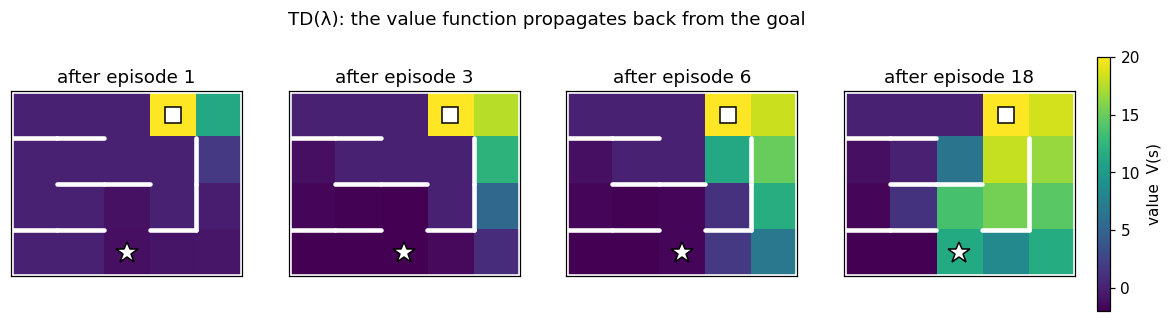

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.0))
order = sorted(V_snaps)
for ax, ep in zip(axes, order):
    Vsnap = V_snaps[ep][0]
    im = ax.imshow(Vsnap, cmap="viridis", vmin=-2, vmax=20)
    draw_maze(ax)
    ax.plot(START[1], START[0], "*", color="w", ms=15, mec="k")
    ax.plot(GOAL[1],  GOAL[0],  "s", color="w", ms=11, mec="k")
    ax.set_title(f"after episode {ep+1}")
fig.colorbar(im, ax=axes, fraction=0.020, pad=0.02, label="value  V(s)")
fig.suptitle("TD(λ): the value function propagates back from the goal", y=1.02)
plt.show()

### The eligibility trace, and the learned policy

**Left:** the eligibility trace $e$ at the end of an episode — a decaying ($\lambda$) "comet tail"
behind the agent. When a reward arrives, *all* cells with a live trace are updated at once, in
proportion to how recently they were visited. This is how credit reaches states that occurred
*before* the outcome.

**Right:** the final value, with the **greedy policy** (arrows) and the agent's shortest learned
path overlaid. The arrows climb the value gradient straight to the goal.

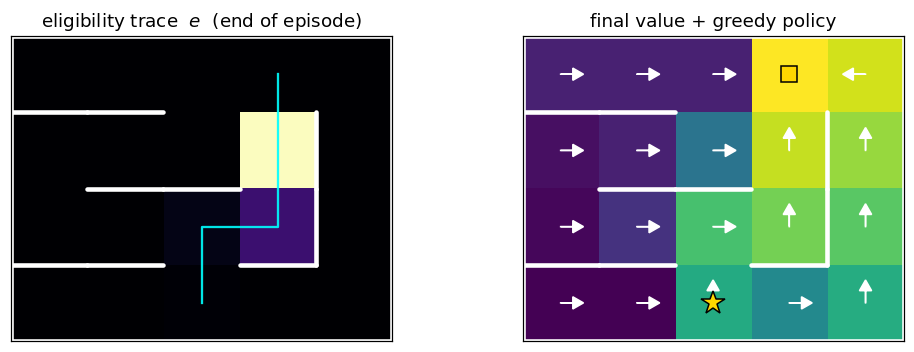

In [5]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 3.6))

# left: an eligibility-trace snapshot + the trajectory that produced it
Vlast, traj_last, EL_last = V_snaps[max(V_snaps)]
axL.imshow(EL_last, cmap="magma", vmin=0, vmax=1)
draw_maze(axL)
ty, tx = zip(*traj_last)
axL.plot(tx, ty, "-", color="cyan", lw=1.5, alpha=0.9)
axL.set_title("eligibility trace  $e$  (end of episode)")

# right: final value + greedy policy arrows + path
axR.imshow(Vlast, cmap="viridis", vmin=-2, vmax=20)
draw_maze(axR)
for r in range(NR):
    for c in range(NC):
        if (r, c) == GOAL:
            continue
        acts = allowed((r, c))
        if len(acts) == 0:
            continue
        vals = [Vlast[r + DELTA[a, 0], c + DELTA[a, 1]] for a in acts]
        a = acts[int(np.argmax(vals))]
        dr, dc = DELTA[a]
        axR.arrow(c, r, 0.30*dc, 0.30*dr, head_width=0.16,
                  head_length=0.14, fc="w", ec="w", length_includes_head=True)
axR.plot(START[1], START[0], "*", color="gold", ms=16, mec="k")
axR.plot(GOAL[1],  GOAL[0],  "s", color="gold", ms=11, mec="k")
axR.set_title("final value + greedy policy")
plt.show()

### Learning curve

Steps needed to reach the goal per episode. With a fixed exploration rate ε = 0.3 the curve stays
noisy, but it settles near the shortest path (4 steps) as the value gradient takes over.

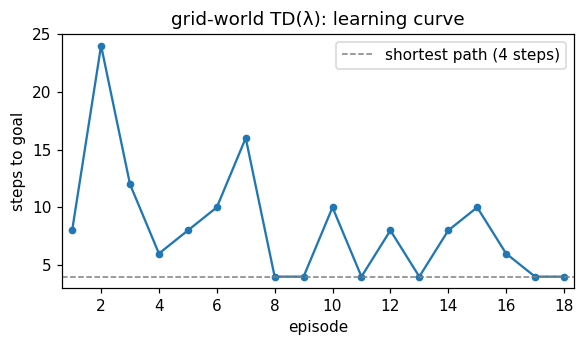

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(np.arange(1, n_episode+1), steps_per_ep, "-o", ms=4)
ax.axhline(4, ls="--", color="gray", lw=1, label="shortest path (4 steps)")
ax.set_xlabel("episode"); ax.set_ylabel("steps to goal")
ax.set_title("grid-world TD(λ): learning curve"); ax.legend(); ax.margins(x=0.02)
plt.show()

## Part 2 — Dopamine as a TD error (Schultz, Dayan & Montague, 1997)

The same TD rule, now in **time** rather than space. A stimulus (cue) appears at $t=1$ s and a
reward arrives at $t=3$ s. Time is represented by a **complete serial compound (CSC)**: after the
cue, each moment activates its own dedicated unit, so the model can learn a separate weight — and
hence a value $V(t)$ — for every post-cue time step.

We run TD(λ) trial after trial (weights **persist across trials**; only the trace resets) and record
the TD error

$$\delta_t = r_t + \gamma\,V(t{+}1) - V(t).$$

The prediction is the celebrated **backward shift**: early on, $\delta$ spikes *at the reward*
(it was unpredicted); with learning, the value ramp predicts the reward, the response *at* reward
vanishes, and a positive $\delta$ appears *at the cue* — exactly the firing pattern Schultz recorded
from midbrain dopamine neurons.

In [7]:
# --- SDM1997 parameters (identical to the MATLAB demo) ---
gamma2, alpha2, lam2 = 0.97, 0.6, 0.8
n_trials = 25

t_step = 5                       # time steps per second
t_max  = 5 * t_step              # total steps (5 s)
t_stim = 1 * t_step              # cue   at 1 s
t_rew  = 3 * t_step              # reward at 3 s
T = (np.arange(1, t_max+1) - t_stim) / t_step       # time axis in seconds (MATLAB-aligned)

# complete serial compound: one active unit per post-cue time step
X = np.zeros((t_max, t_max))
for i in range(1, t_max - t_stim):
    X[i + t_stim - 1, i + t_stim - 1] = 1.0

r = np.zeros(t_max); r[t_rew - 1] = 1.0             # reward delivered at t_rew
w = np.zeros(t_max)                                 # weights -> value V(t) = w . X(:,t)

D_hist = np.zeros((n_trials, t_max))                # TD error per (trial, time)
V_hist = np.zeros((n_trials, t_max))                # value    per (trial, time)
for n in range(n_trials):
    el = np.zeros(t_max)                            # eligibility trace resets each trial
    D  = np.zeros(t_max)
    v  = w @ X
    for t in range(t_max - 1):
        d   = r[t] + gamma2 * v[t+1] - v[t]         # TD error
        el  = lam2 * el + X[t, :]                   # e <- lambda*e + x
        w   = w + alpha2 * el * d                   # weight update (w persists across trials)
        v   = w @ X
        D[t] = d
    D_hist[n] = D
    V_hist[n] = v

print("early-trial δ peaks at T = %.1f s  (reward time)" % T[D_hist[0].argmax()])
print("late-trial  δ peaks at T = %.1f s  (cue time)"    % T[D_hist[-1].argmax()])
print("late-trial  δ at reward time = %.3f  (response has transferred to the cue)"
      % D_hist[-1, t_rew-1])

early-trial δ peaks at T = 2.0 s  (reward time)
late-trial  δ peaks at T = 0.0 s  (cue time)
late-trial  δ at reward time = 0.000  (response has transferred to the cue)


### The TD error migrates from reward to cue

$\delta(t)$ for an early, a middle, and a late trial. The peak walks **backward** in time, step by
step, from the reward (dashed) to the cue (dotted) — the signature of a reward-prediction error
learning to anticipate.

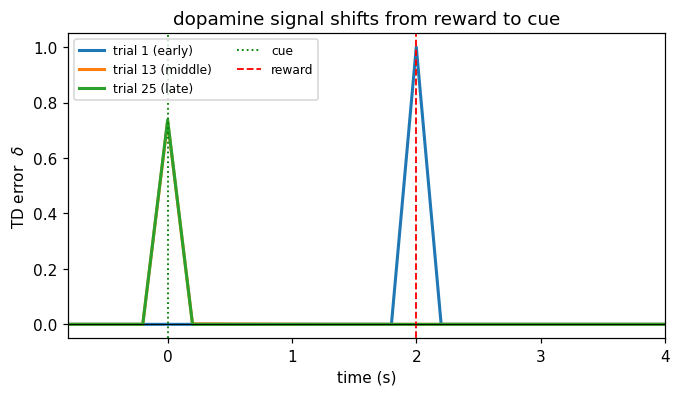

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for n, lab in [(0, "trial 1 (early)"), (n_trials//2, f"trial {n_trials//2+1} (middle)"),
               (n_trials-1, f"trial {n_trials} (late)")]:
    ax.plot(T, D_hist[n], lw=2, label=lab)
ax.axvline((t_stim - t_stim) / t_step, ls=":",  color="green", lw=1.2, label="cue")
ax.axvline((t_rew  - t_stim) / t_step, ls="--", color="red",   lw=1.2, label="reward")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("time (s)"); ax.set_ylabel(r"TD error  $\delta$")
ax.set_xlim(T[0], T[-1]); ax.set_title("dopamine signal shifts from reward to cue")
ax.legend(fontsize=8, ncol=2); plt.show()

### The full picture across learning

**Left:** $\delta$ as a function of time (x) and trial (y). The bright ridge starts at the reward
and slides diagonally to the cue — value is "backed up" one time step per trial.
**Right:** the learned value $V(t)$ at the end of training rises after the cue and peaks just before
the (now fully predicted) reward.

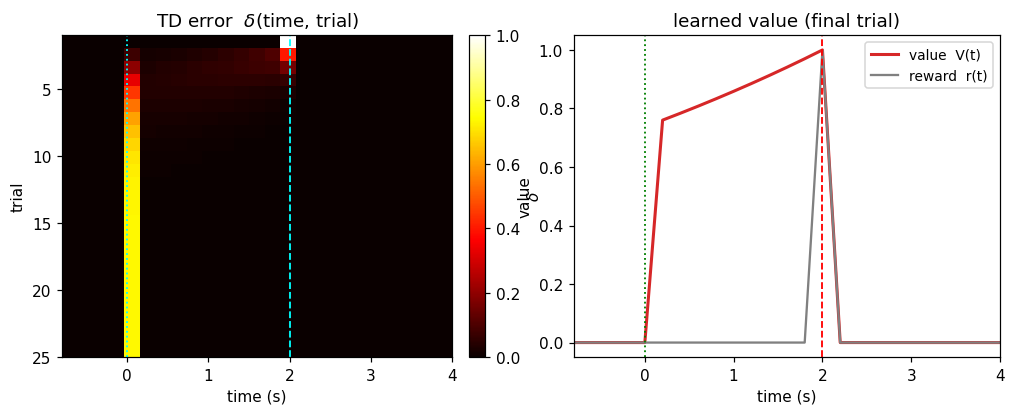

In [9]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 3.8))

im = axL.imshow(D_hist, aspect="auto", cmap="hot",
                extent=[T[0], T[-1], n_trials, 1], vmin=0, vmax=1)
axL.axvline(0, ls=":", color="cyan", lw=1.2)
axL.axvline((t_rew - t_stim) / t_step, ls="--", color="cyan", lw=1.2)
axL.set_xlabel("time (s)"); axL.set_ylabel("trial")
axL.set_title(r"TD error  $\delta$(time, trial)")
fig.colorbar(im, ax=axL, fraction=0.046, pad=0.04, label=r"$\delta$")

axR.plot(T, V_hist[-1], lw=2, color="C3", label="value  V(t)")
axR.plot(T, r, lw=1.5, color="gray", label="reward  r(t)")
axR.axvline(0, ls=":", color="green", lw=1.2)
axR.axvline((t_rew - t_stim) / t_step, ls="--", color="red", lw=1.2)
axR.set_xlabel("time (s)"); axR.set_ylabel("value")
axR.set_xlim(T[0], T[-1]); axR.set_title("learned value (final trial)")
axR.legend(fontsize=9); plt.show()

## Takeaways

- **One rule, two settings.** In space (grid world) and in time (dopamine model) the *same* update
  `V ← V + α · e · δ` does the work. The **eligibility trace** $e$ is what lets a single outcome
  update an entire preceding trajectory — the credit-assignment heart of TD(λ).
- **Value propagates backward.** Reward information flows *back* toward the states/times that predict
  it: across cells in the maze, across time steps in the dopamine model.
- **δ *is* the dopamine reward-prediction error.** The backward shift from reward to cue is one of
  the landmark contacts between a learning rule and a recorded neural signal — and it is the very
  same $\delta$ that will drive the actor–critic in **Demo 4**, here shown as the firing pattern of
  real dopamine neurons.

*The spine, continued:* **2-factor (Hebb/Oja) → objective (infomax/EGHR) → 3-factor (TD / dopamine RPE).**